In [ ]:
! pip install transformers torch bertviz, seaborn, matplotlib, scikit-learn


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [1]:
from transformers import AutoTokenizer, AutoModel
from bertviz import head_view
import torch

/workspaces/ml-supervised-dev/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
model_name = "neuralmind/bert-base-portuguese-cased" # BERTIMBAU
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_attentions=True)

In [ ]:
# Frase de exemplo
sentence = "O Senhor dos Anéis é uma obra escrita por um autor muito conhecido"

# Tokeniza a frase (transforma em IDs numéricos)
inputs = tokenizer(sentence, return_tensors="pt")

# Passa pela rede e coleta as atenções
with torch.no_grad():
    outputs = model(**inputs, output_hidden_states=True)

# Atenções de todas as camadas
attentions = outputs.attentions

print(f"Atenções: {attentions}")

Atenções: (tensor([[[[8.0106e-01, 1.6254e-02, 9.7957e-03,  ..., 8.4201e-03,
           4.2259e-03, 4.6475e-02],
          [4.1234e-01, 9.3847e-03, 1.3444e-02,  ..., 4.9997e-02,
           3.8926e-02, 6.7935e-02],
          [1.5704e-01, 3.7356e-03, 3.0997e-01,  ..., 6.2528e-02,
           6.5049e-02, 7.1265e-02],
          ...,
          [2.3063e-01, 3.5987e-02, 5.4017e-02,  ..., 6.0450e-02,
           4.5822e-02, 4.8377e-02],
          [4.8512e-01, 2.5218e-02, 2.5874e-02,  ..., 1.2889e-02,
           1.2188e-01, 1.7588e-02],
          [1.4219e-01, 2.8604e-02, 1.1254e-02,  ..., 9.0303e-03,
           1.6096e-03, 5.2066e-01]],

         [[1.9237e-01, 3.4224e-02, 3.1371e-02,  ..., 8.4089e-02,
           3.5303e-02, 1.0374e-01],
          [1.5446e-02, 1.5384e-01, 1.2137e-02,  ..., 1.3316e-01,
           2.3322e-02, 5.8886e-02],
          [7.0245e-02, 1.7654e-02, 3.5196e-01,  ..., 7.8826e-02,
           8.9006e-03, 1.6468e-02],
          ...,
          [7.3545e-02, 7.6625e-02, 5.9479e-02,  

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

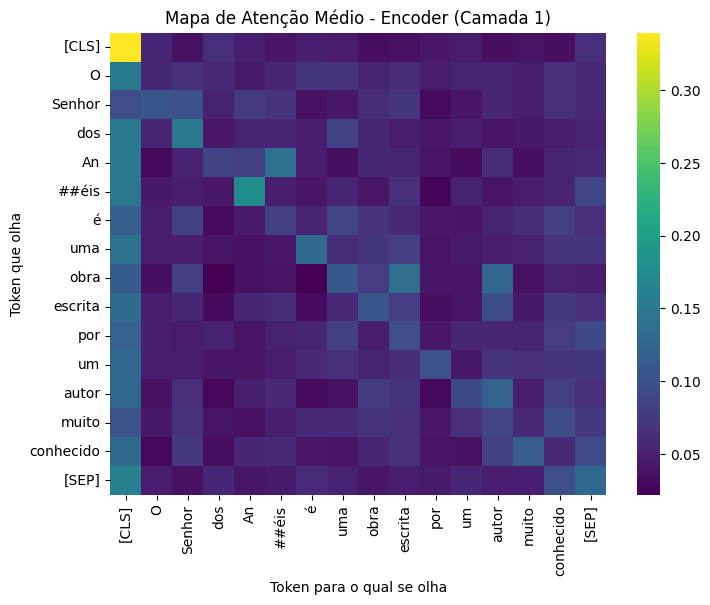

In [24]:
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
att_mean = outputs.attentions[0][0].mean(dim=0)  # média das 12 heads
plt.figure(figsize=(8,6))
sns.heatmap(att_mean, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
plt.title("Mapa de Atenção Médio - Encoder (Camada 1)")
plt.xlabel("Token para o qual se olha")
plt.ylabel("Token que olha")
plt.show()


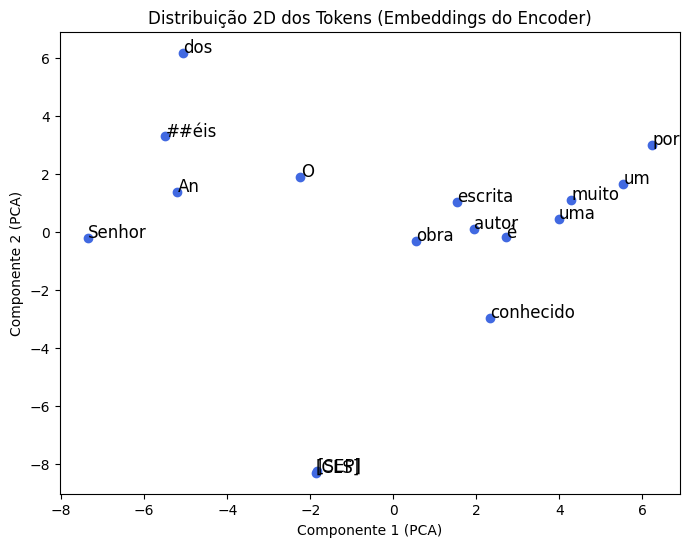

In [ ]:
from sklearn.decomposition import PCA

# Saídas de cada camada (13 = embedding + 12 camadas)
hidden_states = outputs.hidden_states  

# Vetores da última camada
last_layer = hidden_states[-1][0]
pca = PCA(n_components=2) # Precisa ser 2D
embeds_2d = pca.fit_transform(last_layer)

# Gráfico de dispersão
plt.figure(figsize=(8,6))
plt.scatter(embeds_2d[:,0], embeds_2d[:,1], c="royalblue")

# Adiciona rótulos
for i, token in enumerate(tokens):
    plt.text(embeds_2d[i,0]+0.01, embeds_2d[i,1]+0.01, token, fontsize=12)

plt.title("Distribuição 2D dos Tokens (Embeddings do Encoder)")
plt.xlabel("Componente 1 (PCA)")
plt.ylabel("Componente 2 (PCA)")
plt.show()


In [ ]:
# Todos os tokens
tokens

['[CLS]',
 'O',
 'Senhor',
 'dos',
 'An',
 '##éis',
 'é',
 'uma',
 'obra',
 'escrita',
 'por',
 'um',
 'autor',
 'muito',
 'conhecido',
 '[SEP]']